# <b>Machine Learning Model Jupyter Notebook</B>

Supervised learning machine learning model that takes in:
    <li> Chromosome
    <li> Chromosome Start Position
    <li> Chromosome End Position
    <li> Mutated From Allele
    <li> Mutated To Allele

Make sure to run pip install -r requirements.txt

```
python -m venv venv 
source venv/bin/activate   # On Windows: venv\Scripts\activate
pip install pandas numpy scikit-learn scipy
pip freeze > requirements.txt
```


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
mutation_original = pd.read_csv('Mutation_original.csv')

In [59]:
mutation_original_df = mutation_original[['icgc_specimen_id', 'chromosome', 'chromosome_start', 'chromosome_end',
                                            'mutation_type', 'mutated_from_allele', 'mutated_to_allele', 'Cancer type']].copy()

# Add lengths (since larger mutations could be a sign of cancer type?)
mutation_original_df['mutation_length'] = abs(mutation_original_df['chromosome_end'] - mutation_original_df['chromosome_start'] + 1)

# Encode categorical columns
for col in ['chromosome', 'mutation_type', 'mutated_from_allele', 'mutated_to_allele']:
    mutation_original_df[col] = LabelEncoder().fit_transform(mutation_original_df[col])

# Normalise chromosome lengths based on the size of the chromosome it is in
chrom_lengths = {
    '1': 248956422, '2': 242193529, '3': 198295559, '4': 190214555,
    '5': 181538259, '6': 170805979, '7': 159345973, '8': 145138636,
    '9': 138394717, '10': 133797422, '11': 135086622, '12': 133275309,
    '13': 114364328, '14': 107043718, '15': 101991189, '16': 90338345,
    '17': 83257441, '18': 80373285, '19': 58617616, '20': 64444167,
    '21': 46709983, '22': 50818468, 'X': 156040895, 'Y': 57227415
}

mutation_original_df['chromosome_norm_start'] = mutation_original_df.apply(
    lambda x: x['chromosome_start'] / chrom_lengths.get(str(x['chromosome']), 1), axis=1
)
mutation_original_df['chromosome_norm_end'] = mutation_original_df.apply(
    lambda x: x['chromosome_end'] / chrom_lengths.get(str(x['chromosome']), 1), axis=1
)

In [60]:
# X = mutation_original_df.drop(columns=['icgc_specimen_id', 'Cancer type'])
X = mutation_original_df[['chromosome_start', 'chromosome_end', 'mutated_from_allele', 'mutated_to_allele']]
y = mutation_original_df['Cancer type']

# Encode cancer type labels (target variable)
y = LabelEncoder().fit_transform(y)

# Scale features for distance-based models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# knn = KNeighborsClassifier(n_neighbors=5)

# # Train model
# knn.fit(X_train, y_train)

# # Predict on test data
# y_pred = knn.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

# nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean')
# nbrs.fit(X_scaled)

# # Example: find 5 nearest samples to the first mutation entry
# distances, indices = nbrs.kneighbors([X_scaled[0]])
# print("Nearest samples indices:", indices)
# print("Distances:", distances)

Accuracy: 0.3025938025938026

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.28      0.24      7292
           1       0.34      0.40      0.37     11826
           2       0.31      0.35      0.33     13073
           3       0.29      0.25      0.27     10556
           4       0.27      0.18      0.22      7154
           5       0.37      0.29      0.32     10705

    accuracy                           0.30     60606
   macro avg       0.30      0.29      0.29     60606
weighted avg       0.31      0.30      0.30     60606

Nearest samples indices: [[     0      1 180425 295416 127291]]
Distances: [[0.         0.         0.00134823 0.00266565 0.0026671 ]]


In [61]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4744744744744745

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.39      0.38      7292
           1       0.52      0.52      0.52     11826
           2       0.48      0.47      0.48     13073
           3       0.47      0.46      0.46     10556
           4       0.39      0.42      0.41      7154
           5       0.55      0.54      0.55     10705

    accuracy                           0.47     60606
   macro avg       0.46      0.47      0.47     60606
weighted avg       0.48      0.47      0.48     60606



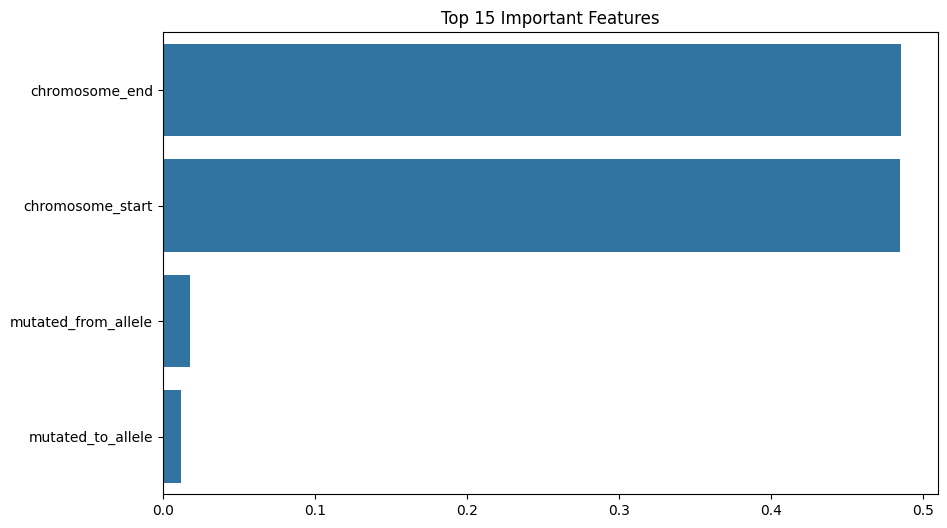

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:15], y=np.array(features)[indices])
plt.title("Top 15 Important Features")
plt.show()

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming you already have X_train, X_test, y_train, y_test

# Define search space for hyperparameters
param_space = {
    'n_estimators': Integer(100, 600),
    'max_depth': Integer(5, 50),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical(['sqrt', 'log2']),
    'bootstrap': Categorical([True, False])
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=30,  # Number of optimization iterations (increase for better results)
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Run optimization
opt.fit(X_train, y_train)

Fitting 10 folds for each of 1 candidates, totalling 10 fits


In [ ]:
print("Best Parameters Found:", opt.best_params_)
print("Best CV Accuracy:", opt.best_score_)

# Predict on test data
y_pred = opt.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
